# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Load Dataset

In [2]:
iris = pd.read_csv('iris.csv')
iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Data Understanding

In [3]:
print(f"The shape of the data : {iris.shape}\n")
print(f"The size of the data: {iris.size}\n")
print(f"Number of Dimension: {iris.ndim}\n")
print(f"Data info: {iris.info()}\n")

The shape of the data : (150, 6)

The size of the data: 900

Number of Dimension: 2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
Data info: None



In [4]:
iris['Species'].unique()


array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

**Drop Unneccessary column**


In [5]:
iris.drop(columns = 'Id', inplace = True)

**Check for Missing Values**

In [6]:
iris.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

There are no missing values in this dataset

**Descriptive Statistics**

In [7]:
iris.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


The table above shows tha our data is fully complete with no missing values. Looking closely at the numbers, Sepals are much bigger than Petals. The petal lengths are widely spread out which usually means the flowers fall into different distinct species. On the other hand, the Sepal widths are almost all the same, hovering right around 3cm.


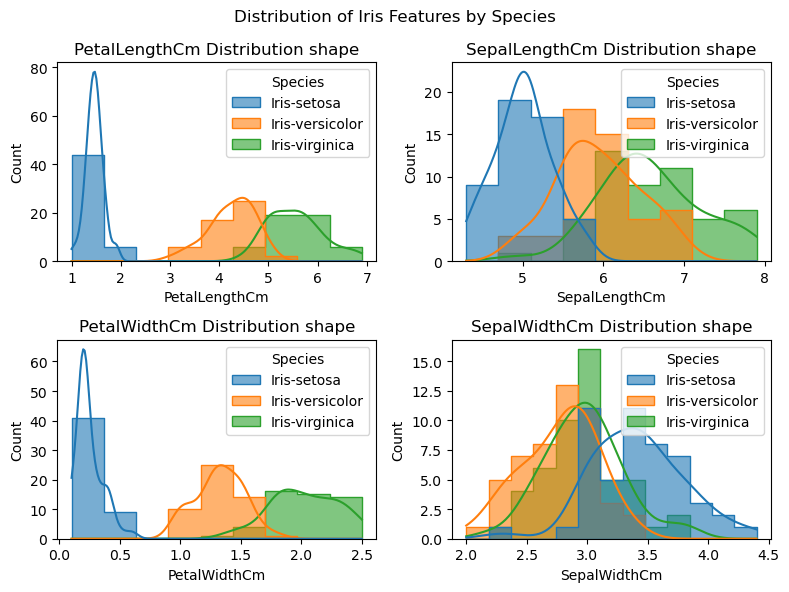

In [8]:
cols = ['PetalLengthCm', 'SepalLengthCm','PetalWidthCm', 'SepalWidthCm']
fig,axes = plt.subplots(nrows= 2, ncols = 2, figsize = (8,6))
flat_axes = axes.flatten()
fig.suptitle("Distribution of Iris Features by Species")
for i, col in enumerate(cols):
    sns.histplot(data = iris, x = col, kde = True, hue = 'Species', element='step',alpha =0.6,ax = flat_axes[i]).set_xlabel(col)
    flat_axes[i].set_title(f"{col} Distribution shape")

plt.tight_layout()
plt.show()

**Insights**

From the plots above:

**Setosa is unique:** On both petal charts, **iris-setosa** (in blue),stands completely alone with tiny petals, making it easily identifiable

**Mixed Lengths:** On the top-right chart ('SepalLengthCm'), the species blend together heavily, but green is generally the largest.

**The overlapping bell curves:** In the 'SepalWidthCm' plot(bottom right), all three species stack closely on top of each other.

**Green is more spread out:** The green Curves(**iris-Virginica**) are wider and fatter than the others

<Figure size 800x600 with 0 Axes>

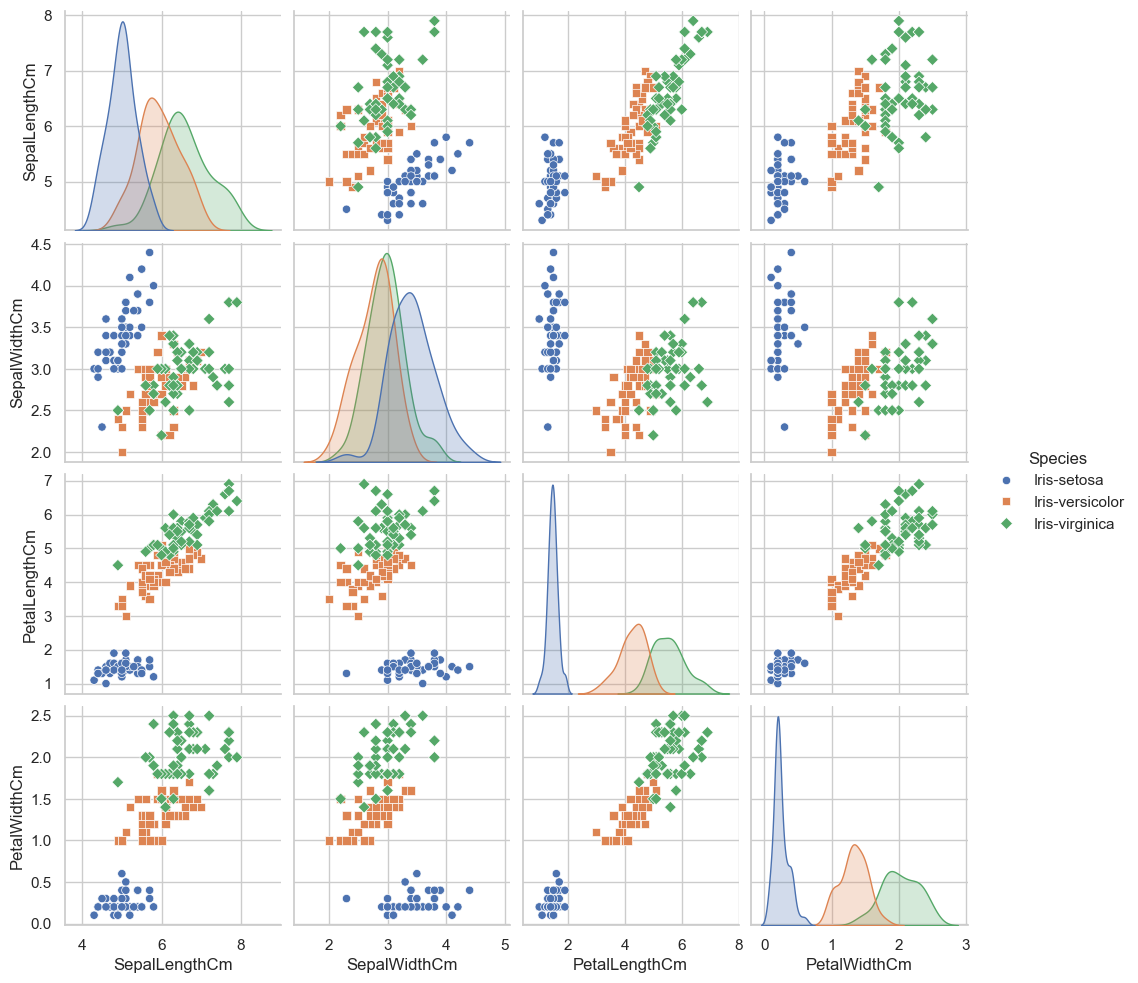

In [9]:
plt.figure(figsize=(8,6))
# Set the visual style for a clean look
sns.set_theme(style = 'whitegrid')
#Generate the pairplot 
sns.pairplot(iris,hue = 'Species', diag_kind= 'kde', markers = ['o','s', 'D'])
plt.show()

**Key Insights from pairplot analysis**

**Species Separation:** **Iris-setosa**(in blue) forms a completely isolated cluster across all scatter plots. This makes it the easiest specie to classify accurately

**Strong Linear Correlation:** A distribution upward diagonal pattern exists between **PetalLengthCm** and **PetalWidthCm**. As PetalLength increases, the PetalWidth increases for all species

**Petals over Sepals:** The orange (**iris-versicolor**) and green color (**iris-virginica**) flowers mix together a lot on the sepal charts while they split into two distinct groups on the petal charts, making petals much better for telling them apart.

**Clear Hillls:** The smooth curves running diagonally down the chart shows that while sepal sizes overlap heavily among all three flowers,petal sizes have a huge, clear gap between the species.

**Encoding the Target column(Species)**

In [10]:
from sklearn.preprocessing import LabelEncoder

#initialize LabelEncoder
le = LabelEncoder()

# Transform the text Species names into numbers (0, 1, 2)
iris['Species'] = le.fit_transform(iris['Species'])
# Confirm the changes
print(iris['Species'].unique())
print(iris.head())


[0 1 2]
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0            5.1           3.5            1.4           0.2        0
1            4.9           3.0            1.4           0.2        0
2            4.7           3.2            1.3           0.2        0
3            4.6           3.1            1.5           0.2        0
4            5.0           3.6            1.4           0.2        0


Text(0.5, 1.0, 'Correlation Matrix')

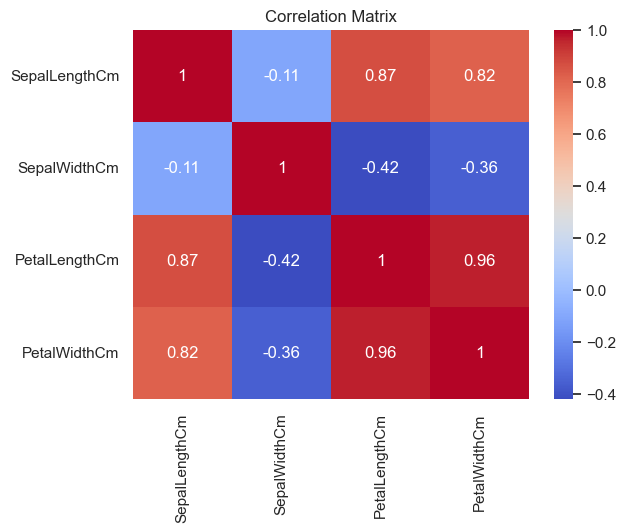

In [11]:
corr_matrix = iris.drop('Species', axis = 1).corr()
sns.heatmap(data = corr_matrix, annot = True, cmap = 'coolwarm')
plt.title("Correlation Matrix")



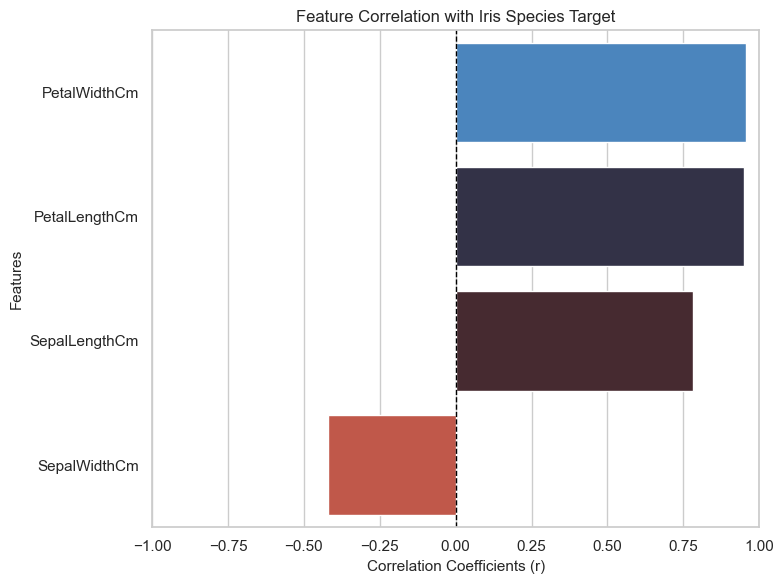

In [12]:
#Ensure target is numeric
#Calculate the correlation matrix for all numeric columns
corr_matrix = iris.corr()

# Extract correlation values relative to 'Species'
# We drop 'Species' itself so it doesn't show a perfect  1.0 correlation with itself
target_corr = corr_matrix['Species'].drop('Species').sort_values(ascending = False)

#Create the horizontal bar plot
plt.figure(figsize = (8,6))
sns.barplot(x = target_corr.values, y = target_corr.index, palette = 'icefire', hue = target_corr.index, legend = False)

#Customizing layouts and titles
plt.title('Feature Correlation with Iris Species Target')
plt.xlabel('Correlation Coefficients (r)',fontsize = 11)
plt.ylabel('Features', fontsize = 11)
plt.axvline(x=0, color = 'black', linestyle = '--',linewidth = 1)
plt.xlim(-1,1)

plt.tight_layout()
plt.show()

**Combined Insights from Correlation Analysis (Heatmap and Barplot)**

**Strongest Positive Links:** PetalWidthCm and PetalLengthCm have the longest bars extending to the right. This means that larger Petals are heavily tied to higher species classes (moving from setosa to virginica)

**Moderate Positive Link:** SepalLength also has a positive link to the target but it is obviously weaker than the petal measurments

**Negative Relationship:** SepalWidth is the only feature  with a red bar extended to the left, this means as sepal width decreases, the species classification index increases (setosa has the widest sepals, while virginica has the narrowest).